<a href="https://colab.research.google.com/github/ambarndt/MVP_Machine-Learning-Analytics_Amanda-Mariano-Bandeira/blob/main/MPV_Machine_Learning_Analytics_Amanda_Mariano_Bandeira.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Amanda Mariano Bandeira  
**Matrícula:** 4052026000525  
**Data:** 05/07/2026  
**Dataset:** Dados de produção do campo de petróleo Polvo - Fonte: ANP ([link](https://app.powerbi.com/view?r=eyJrIjoiNzVmNzI1MzQtNTY1NC00ZGVhLTk5N2ItNzBkMDNhY2IxZTIxIiwidCI6IjQ0OTlmNGZmLTI0YTYtNGI0Mi1iN2VmLTEyNGFmY2FkYzkxMyJ9)) | [link do dataset no GitHub](https://github.com/ambarndt/MVP_Machine-Learning-Analytics_Amanda-Mariano-Bandeira/blob/main/MVP_Machine%20Learning_Produ%C3%A7%C3%A3o%20campo%20Polvo.xlsx)  
**Tipo de problema:** Regressão  


# 1. Definição do problema

## 1.1 Descrição do problema

Na indústria de petróleo, a previsão (forecast) de produção de um campo é fundamental para o planejamento operacional e estratégico de uma operadora. A produção de óleo de um campo tende a seguir um comportamento de declínio ao longo dos anos, à medida em que a energia do reservatório diminui. Esse declínio costuma ser modelado por curva exponencial ou hiperbólica. Contudo, o declínio real é influenciado por diversos fatores: número de poços, intervenções de poços, paradas de produção, injeção de água ou gás, e variação de condição de reservatório. Essas relação podem ser complexas e não-lineares, o que torna o modelo de Machine Learning uma alternativa para a análise.

**Contexto:** O campo de Polvo está localizado na bacia de Campos, atualmente operado pela PRIO (Prio Bravos). Os dados utilizados são públicos, disponibilizados pela ANP e cobrem o período de 2007 a 2026.

**Usuário interessado:** Engenheiros de reservatório em geral.

**Por que é relevante:** Previsões mais acertivas da produção dos próximos anos permitem um melhor planejamento de desenvolvimento e investimentos.


## 1.2 Objetivo do MVP


**Objetivo deste trabalho:**  
> O objetivo deste MVP é construir e avaliar modelo de Machine Learning para prever a produção mensal de óleo do campo de Polvo, agregada por mês, a partir de features temporais e operacionais derivadas do histórico de produção. O trabalho compara a abordagem baseline (regressão linear) com modelos candidatos Random Forest e Gradient Boosting, discutindo suas limitações e desempenho.


## 1.3 Tipo de problema

**Tipo escolhido:** Regressão

**Justificativa:** A variável-alvo é a produção média de óleo em barris por dia, que é uma variável numérica contínua. O objetivo é prever o valor de produção para meses futuros, o que caracteriza um problema de regressão. A divisão dos dados respeita a ordem cronológica, sem embaralhamento, evitando vazamento temporal.

## 1.4 Premissas, hipóteses e critérios de sucesso

**Premissas:**
1. Os dados da ANP são confiáveis e representam a produção real do campo.
2. A agregação mensal do campo (soma dos poços) é uma representação válida para o objetivo deste MVP.
3. Não se possuem dados de subsuperfície (pressão, temperatura etc), apenas dados de produção.

**Hipóteses iniciais:**
1. A produção futura de óleo depende da produção histórica (autocorrelação temporal).
2. O número de poços ativos é fator relevante para a produção total.
3. Indicadores devirados como GOR (razão gás/óleo) e water cut (razão água/óleo) indicam o nível de depleção do reservatório.

**Critérios de sucesso:**
- Métrica principal: MAE (Mean Absolute Error).
- Métricas complementares: RMSE e R².
- Resultado mínimo esperado: Superar o baseline (regressão linear) em pelo menos 10% no MAE.
- Restrição prática: O modelo deve ser simples o suficiente para ser treinado rapidamente no Google Colab.

# 2. Ambiente, bibliotecas e reprodutibilidade


In [616]:
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)

Python: 3.12.13
Seed: 42


## 2.1 Dependências adicionais

Nada a adicionar.


## 2.2 Funções auxiliares


In [617]:
def evaluate_regression(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"MAE": round(mae, 2), "RMSE": round(rmse, 2), "R2": round(r2, 4)}

def show_results_table(results_dict):

  return pd.DataFrame(results_dict).T

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

**Dataset:** Dados mensais de produção de petróleo do campo de Polvo.

**Fonte:** Agência Nacional de Petróleo, Gás Natural e Biocombustíveis - ANP.

**Por que esse dataset foi escolhido:**


*   Dados reais de um campo brasileiro em operação, trazendo relevância ao exercício realizado;
*   Conexão direta com minha área, de engenharia de petróleo;
* Dados públicos e histórico longo, proporcionando uma quantidade de dados suficiente para a análise.

**Restrições e limitações:**


*   Informações de subsuperfície não estão incluídas nos dados;
*   Dados agregados por mês, não havendo produção diária;
* Eventuais paradas operacionais não são diretamente explicitadas no dataset.


## 3.2 Carga dos dados


In [618]:
url = "https://github.com/ambarndt/MVP_Machine-Learning-Analytics_Amanda-Mariano-Bandeira/raw/refs/heads/main/MVP_Machine%20Learning_Produ%C3%A7%C3%A3o%20campo%20Polvo.xlsx"

df_raw=pd.read_excel(url)

print(f"Dataset carregado com sucesso!")
print(f"Formato do dataset: {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas")

df_raw.head(10)

Dataset carregado com sucesso!
Formato do dataset: 3161 linhas x 9 colunas


,Período,Campo,Operadora atual,Poço ANP,Bacia,Óleo (bbl/d),Gás Natural (mil m3/d),Condensado (bbl/d),Água (bbl/d)
0,2008/01,POLVO,Prio Bravo,7-POL-4HP-RJS,Campos,0.00000,0.0,0,0.000000
1,2008/02,POLVO,Prio Bravo,7-POL-4HP-RJS,Campos,0.00000,0.0,0,0.000000
2,2008/03,POLVO,Prio Bravo,7-POL-4HP-RJS,Campos,0.00000,0.0,0,28.709939
3,2008/04,POLVO,Prio Bravo,7-POL-4HP-RJS,Campos,0.00000,0.0,0,0.000000
4,2008/07,POLVO,Prio Bravo,7-POL-1H-RJS,Campos,0.00000,0.0,0,0.000000
5,2008/07,POLVO,Prio Bravo,7-POL-7HP-RJS,Campos,0.00000,0.0,0,0.000000
6,2008/08,POLVO,Prio Bravo,7-POL-7HP-RJS,Campos,0.00000,0.0,0,0.000000
7,2008/09,POLVO,Prio Bravo,7-POL-7HP-RJS,Campos,0.00000,0.0,0,0.000000
8,2008/10,POLVO,Prio Bravo,7-POL-7HP-RJS,Campos,1654.63394,0.0,0,0.000000
9,2008/11,POLVO,Prio Bravo,7-POL-7HP-RJS,Campos,0.00000,0.0,0,0.000000


## 3.3 Visão geral do dataset


In [619]:
print("=" * 50)
print("Formato do dataset")
print("=" * 50)
print(f"\nFormato: {df_raw.shape[0]} registros x {df_raw.shape[1]} atributos")
print(f"\nTipos de dados:")
display(df_raw.dtypes.to_frame("tipo"))

Formato do dataset

Formato: 3161 registros x 9 atributos

Tipos de dados:


,tipo
Período,object
Campo,object
Operadora atual,object
Poço ANP,object
Bacia,object
Óleo (bbl/d),float64
Gás Natural (mil m3/d),float64
Condensado (bbl/d),int64
Água (bbl/d),float64


In [620]:
print(f"\nValores ausentes por coluna:")
display(df_raw.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
Período,0
Campo,0
Operadora atual,0
Poço ANP,0
Bacia,0
Óleo (bbl/d),0
Gás Natural (mil m3/d),0
Condensado (bbl/d),0
Água (bbl/d),0


In [621]:
print("\nDuplicatas:", df_raw.duplicated().sum())



Duplicatas: 0


In [622]:
display(df_raw.sample(5, random_state=SEED))

,Período,Campo,Operadora atual,Poço ANP,Bacia,Óleo (bbl/d),Gás Natural (mil m3/d),Condensado (bbl/d),Água (bbl/d)
139,2012/02,POLVO,Prio Bravo,7-POL-20H-RJS,Campos,0.000000,0.000000,0,0.000000
864,2015/11,POLVO,Prio Bravo,7-POL-15H-RJS,Campos,167.299931,0.277465,0,1174.526412
291,2015/02,POLVO,Prio Bravo,7-POL-5HA-RJS,Campos,0.000000,0.000000,0,0.000000
1242,2015/11,POLVO,Prio Bravo,7-POL-13H-RJS,Campos,112.710041,0.717600,0,2777.879701
599,2025/06,POLVO,Prio Bravo,7-POL-7HP-RJS,Campos,0.000000,0.000000,0,0.000000


## 3.4 Dicionário de dados

Preencha a tabela abaixo com os principais atributos.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| Período | data (AAAA/MM) | Ano/mês de produção | Sim | Será convertida em datetime para gerar features temporais |
| Campo | categórica | Nome do campo (Polvo) | Não | Todos os dados são do mesmo campo |
| Operadora atual | categórica | Operadora do campo (PRIO - Prio Bravo) | Não | Dado constante |
| Poço ANP | categórica | Nome do poço | Não | Será usado na agregação |
| Bacia | categórica | Bacia sedimentar onde o campo está localizado | Não | Dado constante |
| Óleo (bbl/d) | numérica | Produção de óleo | Sim (variável-alvo) | Produção mensal por poço agregada para o campo |
| Gás natural (mil m³/d) | numérica | Produção de gás natural | Sim (feature) | Usada para calcular GOR |
| Condensado (bbl/d) | numérica | Produção de condensado | Não | Não há produção de condensado |
| Água (bbl/d) | numérica | Produção de água | Sim | Usada para calcular water cut |

# 4. Análise exploratória dos dados

In [623]:
TARGET = "oleo_total_bbl_d"
PROBLEM_TYPE = "regressao"

#Conversão da coluna "Período" para datetime
df_raw["data"]=pd.to_datetime(df_raw["Período"], format="%Y/%m")

#Verificação da conversão
print("Período mínimo:", df_raw["data"].min())
print("Período máximo:", df_raw["data"].max())
print("Número de meses distintos:", df_raw["data"].nunique())
print("Número de poços distintos:", df_raw["Poço ANP"].nunique())

Período mínimo: 2007-08-01 00:00:00
Período máximo: 2026-05-01 00:00:00
Número de meses distintos: 226
Número de poços distintos: 24


In [624]:
# === Agregação dos dados por mês (nível campo) ===
# Para cada mês, calcular a produção total do campo (soma de todos os poços)

df_monthly = df_raw.groupby("data").agg(
    oleo_total_bbl_d=("Óleo (bbl/d)", "sum"),
    gas_total_mil_m3_d=("Gás Natural (mil m3/d)", "sum"),
    agua_total_bbl_d=("Água (bbl/d)", "sum"),
    n_pocos_ativos=("Poço ANP", "nunique")
).reset_index()

# Ordenar por data
df_monthly = df_monthly.sort_values("data").reset_index(drop=True)

print(f"Dados agregados: {df_monthly.shape[0]} meses")
df_monthly.head(10)

Dados agregados: 226 meses


,data,oleo_total_bbl_d,gas_total_mil_m3_d,agua_total_bbl_d,n_pocos_ativos
0,2007-08-01,4340.815792,7.425355,22.206276,2
1,2007-09-01,8575.126922,13.173100,37.407597,3
2,2007-10-01,7052.879604,10.854677,313.624129,3
3,2007-11-01,5354.519446,8.311600,534.369678,3
4,2007-12-01,6853.243064,9.891290,985.774936,3
5,2008-01-01,3872.145006,5.945129,1677.256966,3
6,2008-02-01,3046.145440,4.598379,1068.679928,3
7,2008-03-01,4323.481482,6.479935,1846.552275,4
8,2008-04-01,4376.294440,6.241733,1905.709696,4
9,2008-05-01,7561.091383,11.842146,2026.356639,5


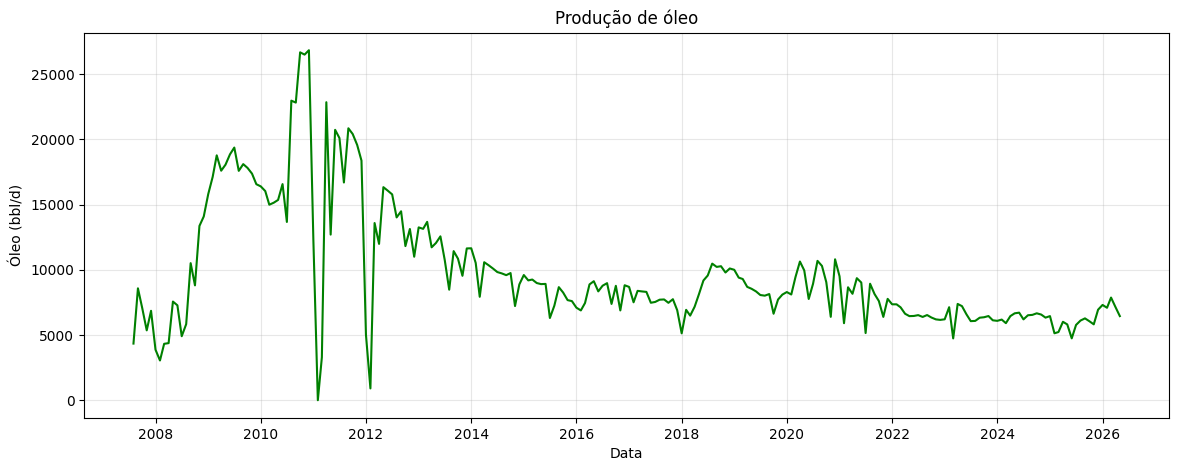

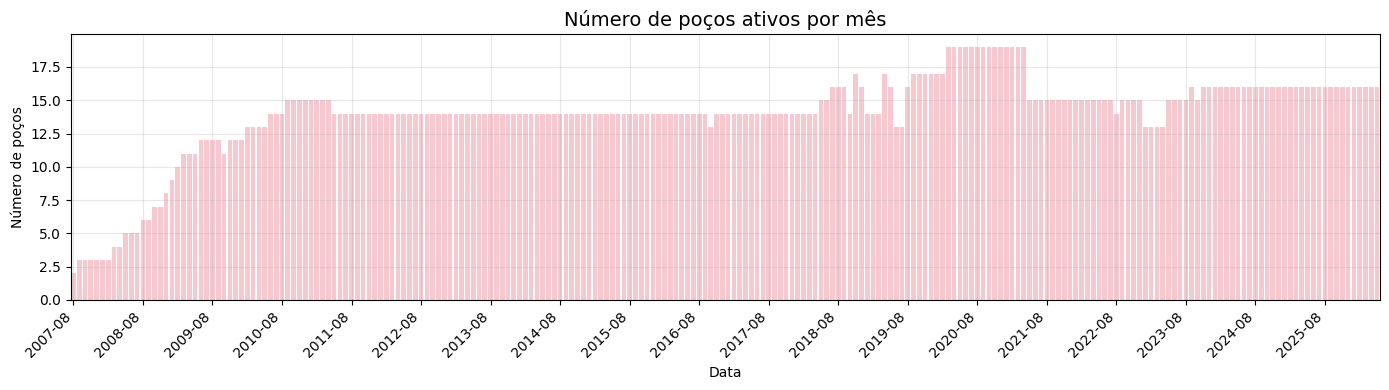

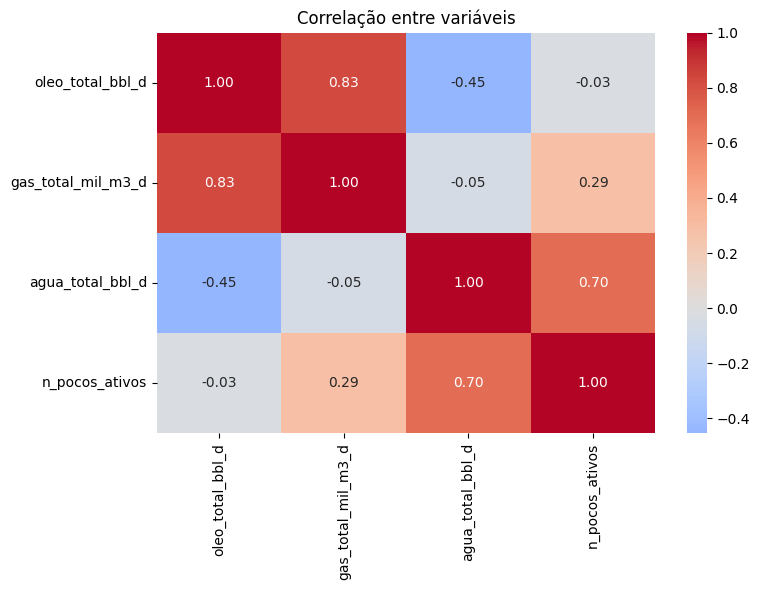

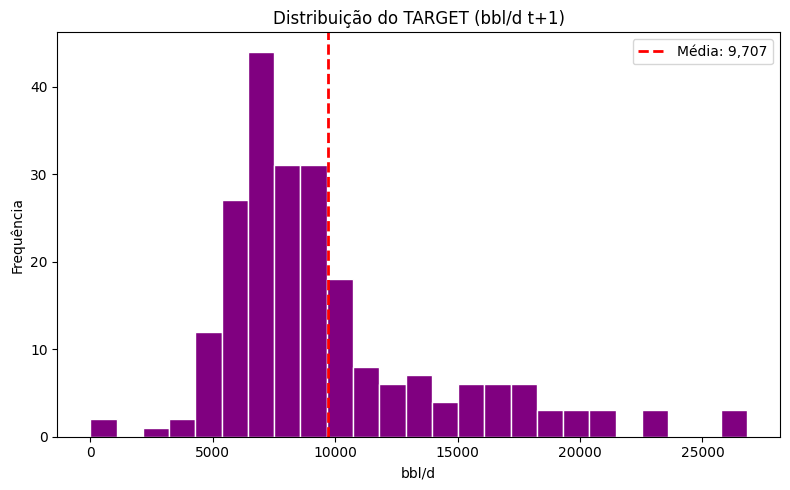


Estatísticas descritivas da variável-alvo:


,oleo_total_bbl_d
count,226.000000
mean,9707.292426
std,4614.923093
min,0.000000
25%,6595.699868
50%,8339.137526
75%,10786.814901
max,26825.333568


In [625]:
#Gráfico 1: produção de óleo ao longo do tempo
plt.figure(figsize=(14, 5))
plt.plot(df_monthly["data"], df_monthly["oleo_total_bbl_d"], color="green", linewidth=1.5)
plt.title(f"Produção de óleo")
plt.xlabel("Data")
plt.ylabel("Óleo (bbl/d)")
plt.grid(True, alpha=0.3)
plt.show()

#Gráfico 2: número de poços ativos ao longo do tempo
plt.figure(figsize=(14, 4))
sns.barplot(x=df_monthly["data"], y=df_monthly["n_pocos_ativos"], color="pink")
plt.title(f"Número de poços ativos por mês", fontsize=14)
plt.xlabel("Data")
plt.ylabel("Número de poços")
plt.grid(True, alpha=0.3)

all_dates = df_monthly["data"].dt.strftime('%Y-%m').unique()
selected_indices = np.arange(0, len(all_dates), 12)
selected_labels = [all_dates[i] for i in selected_indices]
selected_positions = [i for i in selected_indices]

plt.xticks(selected_positions, selected_labels, rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Gráfico 3: correlação entre variáveis
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_monthly[["oleo_total_bbl_d", "gas_total_mil_m3_d", "agua_total_bbl_d", "n_pocos_ativos"]].corr(),
    annot=True, cmap="coolwarm", center=0, fmt=".2f"
)
plt.title("Correlação entre variáveis")
plt.tight_layout()
plt.show()

# Gráfico 4: distribuição do target
plt.figure(figsize=(8, 5))
plt.hist(df_monthly["oleo_total_bbl_d"], bins=25, color="purple", edgecolor="white")
plt.axvline(df_monthly["oleo_total_bbl_d"].mean(), color="red", lw=2, linestyle="--", label=f"Média: {df_monthly['oleo_total_bbl_d'].mean():,.0f}")
plt.title("Distribuição do TARGET (bbl/d t+1)")
plt.xlabel("bbl/d")
plt.ylabel("Frequência")
plt.legend()
plt.tight_layout()
plt.show()

# Estatísticas descritivas
print("\nEstatísticas descritivas da variável-alvo:")
display(df_monthly["oleo_total_bbl_d"].describe().to_frame("oleo_total_bbl_d"))


## 4.1 Síntese da análise exploratória

Escreva aqui os principais achados da EDA.

**Síntese:**  
1. **Tendência de declínio:** A produção de óleo apresenta um comportamento de declínio ao longo do tempo. Após um período inicial de ramp-up (no início dos novos poços), a produção atinge um pico e depois declina progressivamente.

2. **Número de poços:** O número de poços ativos variou ao longo do tempo, com entrada de novos poços em diferentes fases do desenvolvimento do campo. Essa variável é relevante porque cada novo poço contribui para a produção total.

3. **Ausência de valores ausentes:** O dataset da ANP não apresenta valores ausentes nas variáveis numéricas de produção, o que simplifica o pré-processamento.

4. **Escala das variáveis:** As variáveis numéricas (óleo, gás, água) têm escalas diferentes, o que justifica a normalização para alguns modelos.

5. **Correlação:** Óleo e gás tendem a ser correlacionados (produção associada). A produção de água geralmente aumenta ao longo da vida do campo (water cut crescente), o que é um indicador de depleção.

# 5. Preparação dos dados e divisão treino/teste

In [626]:
#Engenharia de features

#Cópia
df = df_monthly.copy()

# 1. Meses desde o início da produção do campo
df["meses_produzindo"] = range(1, len(df) + 1)

# 2. Ano e mês (sazonalidade básica)
df["ano"] = df["data"].dt.year
df["mes"] = df["data"].dt.month

# 3. Lags da produção de óleo (produção dos meses anteriores)
df["oleo_lag1"] = df["oleo_total_bbl_d"].shift(1)
df["oleo_lag2"] = df["oleo_total_bbl_d"].shift(2)
df["oleo_lag3"] = df["oleo_total_bbl_d"].shift(3)

# 4. Média móvel dos últimos 3 meses
df["oleo_media_movel_3m"] = df["oleo_total_bbl_d"].shift(1).rolling(window=3).mean()

# 5. Water cut = água / (água + óleo)
df["water_cut"] = df["agua_total_bbl_d"] / (df["agua_total_bbl_d"] + df["oleo_total_bbl_d"])

# 6. GOR (Gas-Oil Ratio) = gás / óleo
# Converter gás para mesma base: mil m³/d para m³/d, depois converter para boe
df["GOR"] = df["gas_total_mil_m3_d"] / df["oleo_total_bbl_d"].replace(0, np.nan)

# 7. Remover as primeiras linhas que ficaram com NaN por causa dos lags
df = df.dropna().reset_index(drop=True)

print(f"Dataset após engenharia de features: {df.shape[0]} registros x {df.shape[1]} colunas")
print(f"\nFeatures criadas:")
print("- meses_produzindo: tempo desde o início da produção")
print("- ano, mes: componentes temporais para capturar sazonalidade")
print("- oleo_lag1, oleo_lag2, oleo_lag3: produção dos 1, 2 e 3 meses anteriores")
print("- oleo_media_movel_3m: média móvel de 3 meses (defasada)")
print("- water_cut: razão água/(água+óleo) — indicador de maturidade do reservatório")
print("- GOR: razão gás/óleo")

df.head()

Dataset após engenharia de features: 222 registros x 14 colunas

Features criadas:
- meses_produzindo: tempo desde o início da produção
- ano, mes: componentes temporais para capturar sazonalidade
- oleo_lag1, oleo_lag2, oleo_lag3: produção dos 1, 2 e 3 meses anteriores
- oleo_media_movel_3m: média móvel de 3 meses (defasada)
- water_cut: razão água/(água+óleo) — indicador de maturidade do reservatório
- GOR: razão gás/óleo


,data,oleo_total_bbl_d,gas_total_mil_m3_d,agua_total_bbl_d,n_pocos_ativos,meses_produzindo,ano,mes,oleo_lag1,oleo_lag2,oleo_lag3,oleo_media_movel_3m,water_cut,GOR
0,2007-11-01,5354.519446,8.311600,534.369678,3,4,2007,11,7052.879604,8575.126922,4340.815792,6656.274106,0.090742,0.001552
1,2007-12-01,6853.243064,9.891290,985.774936,3,5,2007,12,5354.519446,7052.879604,8575.126922,6994.175324,0.125752,0.001443
2,2008-01-01,3872.145006,5.945129,1677.256966,3,6,2008,1,6853.243064,5354.519446,7052.879604,6420.214038,0.302241,0.001535
3,2008-02-01,3046.145440,4.598379,1068.679928,3,7,2008,2,3872.145006,6853.243064,5354.519446,5359.969172,0.259715,0.001510
4,2008-03-01,4323.481482,6.479935,1846.552275,4,8,2008,3,3046.145440,3872.145006,6853.243064,4590.511170,0.299277,0.001499


In [627]:
#Definição de features e do target

TARGET = "oleo_total_bbl_d"

FEATURES = [
    "meses_produzindo",
    "n_pocos_ativos",
    "oleo_lag1",
    "oleo_lag2",
    "oleo_lag3",
    "oleo_media_movel_3m",
    "water_cut",
    "GOR",
    "mes"]

X = df[FEATURES]
y = df[TARGET]

print(f"Variável-alvo: {TARGET}")
print(f"Número de features: {len(FEATURES)}")
print(f"Features: {FEATURES}")
print(f"\nTotal de registros disponíveis para modelagem: {len(X)}")



Variável-alvo: oleo_total_bbl_d
Número de features: 9
Features: ['meses_produzindo', 'n_pocos_ativos', 'oleo_lag1', 'oleo_lag2', 'oleo_lag3', 'oleo_media_movel_3m', 'water_cut', 'GOR', 'mes']

Total de registros disponíveis para modelagem: 222


In [628]:
# === Divisão dos dados ===

# Por se tratar de dados com dependência temporal, não é usada divisão aleatória.
# Os dados mais antigos são usados para treino e os mais recentes para teste.

split_ratio = 0.7
split_index = int(len(df) * split_ratio)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Divisão temporal (70/30):")
print(f"  Treino: {X_train.shape[0]} meses — de {df['data'].iloc[0].strftime('%Y-%m')} a {df['data'].iloc[split_index-1].strftime('%Y-%m')}")
print(f"  Teste:  {X_test.shape[0]} meses — de {df['data'].iloc[split_index].strftime('%Y-%m')} a {df['data'].iloc[-1].strftime('%Y-%m')}")


Divisão temporal (70/30):
  Treino: 155 meses — de 2007-11 a 2020-10
  Teste:  67 meses — de 2020-11 a 2026-05


## 5.1 Justificativa da divisão

**Resposta:**  

**Por que divisão temporal?**

Como os dados representam uma série temporal de produção, se fossem embaralhados, causariam vazamento de dados e o modelo teria acesso a informações futuras durante o treinamento. A divisão temporal (70% mais antigos para treino, 30% mais recentes para teste) simula o cenário real, onde se usa o passado para projetar o futuro, e sua proporção é adequada. Não houve estratificação de classes pois a variável-alvo é contínua.

**Prevenção de vazamento de dados:** Os lags são calculados a partir de dados passados. Nenhuma informação do conjunto de teste é utilizada em qualquer etapa do pré-processamento. A otimização de hiperparâmetros utilizada TimeSeriesSplit, que respeita a ordem cronológica.

# 6. Pré-processamento e pipeline


In [629]:
#Normalização
scaler = StandardScaler()

# Ajustar (fit) apenas no treino
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=FEATURES,
    index=X_train.index)

# Aplicar (transform) no teste
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=FEATURES,
    index=X_test.index)

print("Normalização aplicada com StandardScaler.")
print("Fit realizado apenas no conjunto de treino para evitar vazamento de dados.")
print(f"\nMédias no treino (após normalização): todas ~ 0")
print(f"Desvios-padrão no treino (após normalização): todos ~ 1")
X_train_scaled.describe().loc[["mean", "std"]].round(2)



Normalização aplicada com StandardScaler.
Fit realizado apenas no conjunto de treino para evitar vazamento de dados.

Médias no treino (após normalização): todas ~ 0
Desvios-padrão no treino (após normalização): todos ~ 1


,meses_produzindo,n_pocos_ativos,oleo_lag1,oleo_lag2,oleo_lag3,oleo_media_movel_3m,water_cut,GOR,mes
mean,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 6.1 Decisões de pré-processamento

**Resposta:**  

**Escolhas feitas:**

1. Agregação por campo/mês (soma): Reduz o nível de granularidade para previsão no nível do campo.
2. Criação de lags (1, 2 e 3 meses): Captura a dependência temporal e a tendência de declínio.
3. Média móvel de 3 meses: Suaviza flutuações pontuais e captura tendência recente.
4. GOR e water cut: Indicadores de engenharia de reservatório que demonstram a  maturidade do campo.
5. Meses produzindo: Proxy para o tempo de depleção do reservatório.
6. Mês do ano: Capturar possível sazonalidade operacional.
7. Número de poços ativos: Fator operacional que afeta diretamente a produção total.

* Não foi necessário tratamento de outliers, porque a produção de óleo varia naturalmente ao longo da vida do campo.




# 7. Baseline e modelos candidatos


In [630]:
# === Definição de baseline e modelos candidatos ===

models = {
    "Baseline (Regressão Linear)": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=SEED),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=SEED)
}

print("Modelos candidatos:")
for name in models:
  print(f"  - {name}")

Modelos candidatos:
  - Baseline (Regressão Linear)
  - Random Forest
  - Gradient Boosting


## 7.1 Justificativa dos modelos

**Resposta:**  

**Regressão Linear (Baseline)**: Modelo mais simples para regressão. Serve como referência mínima de desempenho.

**Random Forest**: Ensemble de árvores de decisão que captura não-linearidades automaticamente. Robusto a outliers.

**Gradient Boosting**: Constrói árvores de forma sequencial, onde cada nova árvore corrige os erros da anterior. Mais sensível a hiperparâmetros.

* O dataset é relativamente pequeno e manter a solução simples e interpretável é um critério deste MVP.

# 8. Treinamento e avaliação inicial


In [631]:
results = {}
trained_models = {}

for name, model in models.items():
  t0 = time.time()
  model.fit(X_train_scaled, y_train)
  train_time = time.time() - t0

  y_pred = model.predict(X_test_scaled)
  metrics = evaluate_regression(y_test, y_pred)
  metrics["tempo_treino_s"] = round(train_time, 3)

  results[name] = metrics
  trained_models[name] = model

  print(f"\n{name}:")
  print(f"  MAE  = {metrics['MAE']} bbl/d")
  print(f"  RMSE = {metrics['RMSE']} bbl/d")
  print(f"  R²   = {metrics['R2']}")
  print(f"  Tempo de treino: {metrics['tempo_treino_s']}s")

# Tabela comparativa
print("\n" + "=" * 60)
print("COMPARAÇÃO DOS MODELOS")
print("=" * 60)
display(show_results_table(results))


Baseline (Regressão Linear):
  MAE  = 4904.5 bbl/d
  RMSE = 5341.15 bbl/d
  R²   = -22.8853
  Tempo de treino: 0.005s

Random Forest:
  MAE  = 967.18 bbl/d
  RMSE = 1211.66 bbl/d
  R²   = -0.2292
  Tempo de treino: 0.383s

Gradient Boosting:
  MAE  = 664.51 bbl/d
  RMSE = 973.46 bbl/d
  R²   = 0.2066
  Tempo de treino: 0.17s

COMPARAÇÃO DOS MODELOS


,MAE,RMSE,R2,tempo_treino_s
Baseline (Regressão Linear),4904.50,5341.15,-22.8853,0.005
Random Forest,967.18,1211.66,-0.2292,0.383
Gradient Boosting,664.51,973.46,0.2066,0.170


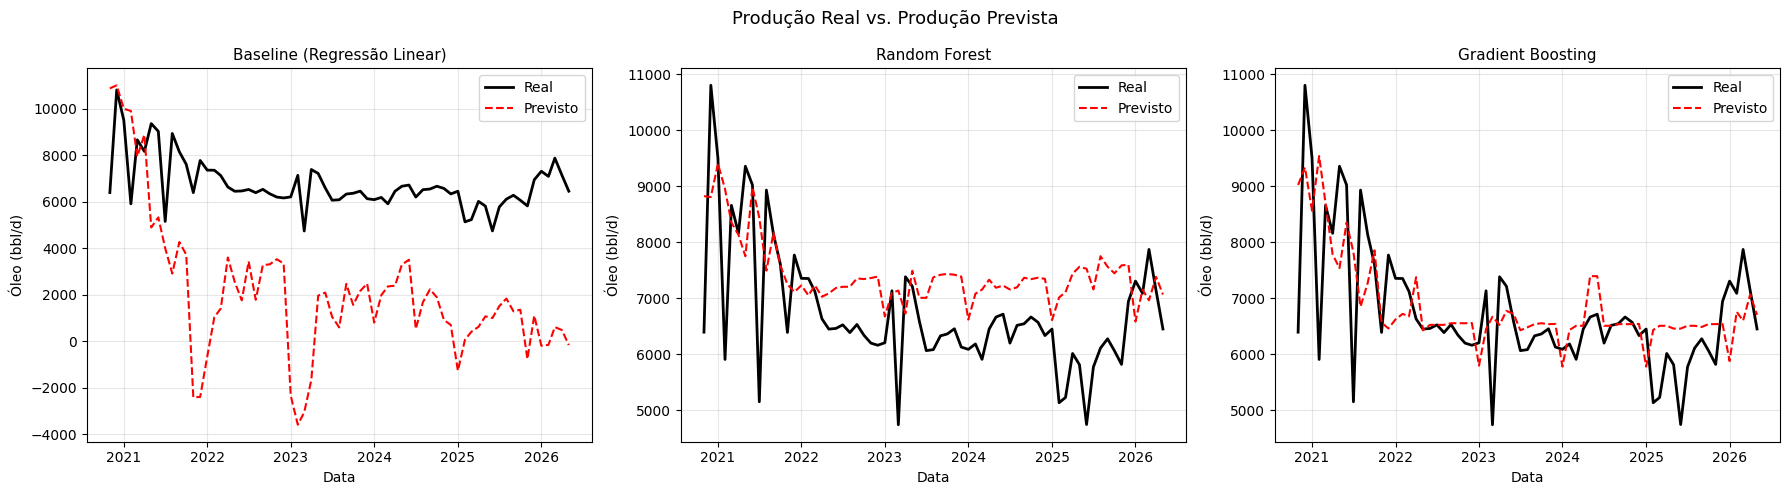

In [632]:
# === Gráfico: Real vs. Previsto para cada modelo ===

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dates_test = df["data"].iloc[split_index:].values

for ax, (name, model) in zip(axes, trained_models.items()):
  y_pred = model.predict(X_test_scaled)
  ax.plot(dates_test, y_test.values, label="Real", color="black", linewidth=2)
  ax.plot(dates_test, y_pred, label="Previsto", color="red", linestyle="--", linewidth=1.5)
  ax.set_title(name, fontsize=11)
  ax.set_xlabel("Data")
  ax.set_ylabel("Óleo (bbl/d)")
  ax.legend()
  ax.grid(True, alpha=0.3)

plt.suptitle("Produção Real vs. Produção Prevista", fontsize=13)
plt.tight_layout()
plt.show()

## 8.1 Análise dos resultados iniciais

**Resposta:**  

**Interpretação:**

- O Gradient Boosting apresentou o melhor desempenho, superando o baseline em 86% no MAE. Isso indica que as relações entre as features e a produção são predominantementes não-lineares.

- O Random Forest também superou o baseline, com redução de 80% no MAE.

- O baseline teve desempenho inferior, indicando que uma relação linear simples não é adequada para esse exercício.

Os modelos candidatos superaram o baseline, validando a hipótese de que Machine Learning pode agregar valor quando se busca saber a previsão de produção de óleo, em uma relação não-linear entre os dados.

# 9. Validação e otimização de hiperparâmetros

In [633]:
# === Otimização de hiperparâmetros ===

search = None

if PROBLEM_TYPE == "classificacao":
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "f1_weighted"

elif PROBLEM_TYPE == "regressao":
    cv = TimeSeriesSplit(n_splits=5)
    model_to_tune = GradientBoostingRegressor(random_state=SEED)
    param_dist = {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.05, 0.1]
    }
    scoring = "neg_mean_absolute_error"

elif PROBLEM_TYPE == "serie_temporal":
    cv = TimeSeriesSplit(n_splits=5)
    model_to_tune = None
    param_dist = None
    scoring = None
    print("Para séries temporais, configure um modelo compatível com features temporais e TimeSeriesSplit.")

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, avalie diferentes valores de k e interprete os perfis dos grupos.")
    model_to_tune = None
    param_dist = None
    scoring = None

if model_to_tune is not None:
    search = GridSearchCV(
        model_to_tune,
        param_grid=param_dist,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        verbose=1
    )
    search.fit(X_train_scaled, y_train)

    print("Melhor score na validação:", search.best_score_)
    print("Melhores hiperparâmetros:", search.best_params_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Melhor score na validação: -2009.7509205239999
Melhores hiperparâmetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}


In [634]:
# === Avaliação do modelo otimizado no conjunto de teste ===

best_model = search.best_estimator_
y_pred_optimized = best_model.predict(X_test_scaled)

for name, model in models.items():
  t0 = time.time()
  model.fit(X_train_scaled, y_train)
  train_time = time.time() - t0

metrics_optimized = evaluate_regression(y_test, y_pred_optimized)
metrics["tempo_treino_s"] = round(train_time, 3)

print("Desempenho do Gradient Boosting OTIMIZADO no conjunto de teste:")
print(f"  MAE  = {metrics_optimized['MAE']} bbl/d")
print(f"  RMSE = {metrics_optimized['RMSE']} bbl/d")
print(f"  R²   = {metrics_optimized['R2']}")
print(f"  Tempo de treino: {metrics['tempo_treino_s']}s")

# Comparação com modelo sem otimização

print(f"\nComparação com Gradient Boosting SEM otimização:")
print(f"  MAE antes:  {results['Gradient Boosting']['MAE']} bbl/d")
print(f"  MAE depois: {metrics_optimized['MAE']} bbl/d")

melhora = results['Gradient Boosting']['MAE'] - metrics_optimized['MAE']
print(f"  Melhora no MAE: {melhora:.2f} bbl/d")


Desempenho do Gradient Boosting OTIMIZADO no conjunto de teste:
  MAE  = 769.5 bbl/d
  RMSE = 1034.66 bbl/d
  R²   = 0.1037
  Tempo de treino: 0.131s

Comparação com Gradient Boosting SEM otimização:
  MAE antes:  664.51 bbl/d
  MAE depois: 769.5 bbl/d
  Melhora no MAE: -104.99 bbl/d


## 9.1 Discussão da otimização

**Resposta:**  

**A otimização melhorou o resultado?**  
Não. O Gradient Boosting otimizado ficou pior que o modelo com hiperparâmetros default. Algumas possibilidades:

1. O dataset é pequeno, e com poucos dados de treino, o TimeSeriesSplit gera folds pequenos, e a busca pode otimizar para um subconjunto não representativo.
2. Overfitting na validação. A busca encontrou parâmetros que funcionam bem nos folds de validação mas não generalizaram para o teste real.
3. Hiperparâmetros default já são adequados no Gradient Boosting, são razoáveis.

# 10. Avaliação final no conjunto de teste

In [635]:
final_model_plot = trained_models["Gradient Boosting"]
y_pred_final_model = final_model_plot.predict(X_test_scaled)


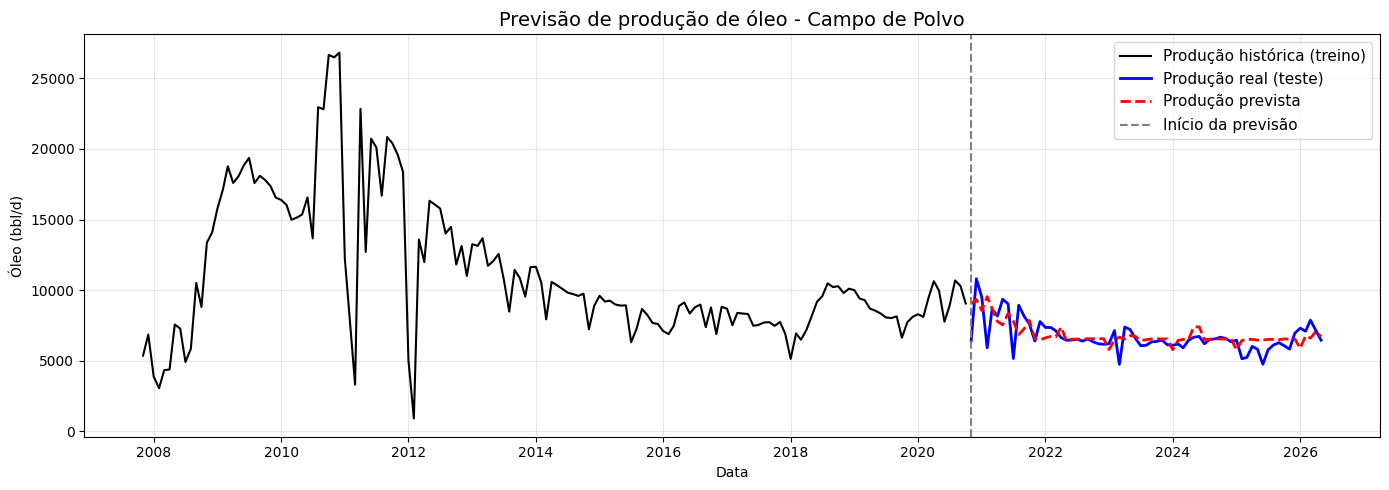

A linha preta é o histórico que o modelo usou para aprender
A linha azul é o que realmente aconteceu no período
A linha vermelha tracejada é ao que o modelo previu para o período


In [636]:
#Gráfico completo: histórico (treino) + previsão (teste)

dates_train = df["data"].iloc[:split_index].values
dates_test = df["data"].iloc[split_index:].values

plt.figure(figsize=(14, 5))

#Dados de treino (histórico usado para aprender)
plt.plot(dates_train, y_train.values, label="Produção histórica (treino)", color="black", linewidth=1.5)

#Dados reais do período de teste
plt.plot(dates_test, y_test.values, label="Produção real (teste)", color="blue", linewidth=2)

#Previsão do modelo para o futuro
plt.plot(dates_test, y_pred_final_model, label="Produção prevista", color="red", linestyle="--", linewidth=2)

#Linha vertical separando treino e teste
plt.axvline(x=dates_test[0], color="gray", linestyle="--", linewidth=1.5, label="Início da previsão")

plt.title("Previsão de produção de óleo - Campo de Polvo", fontsize=14)
plt.xlabel("Data")
plt.ylabel("Óleo (bbl/d)")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("A linha preta é o histórico que o modelo usou para aprender")
print("A linha azul é o que realmente aconteceu no período")
print("A linha vermelha tracejada é ao que o modelo previu para o período")

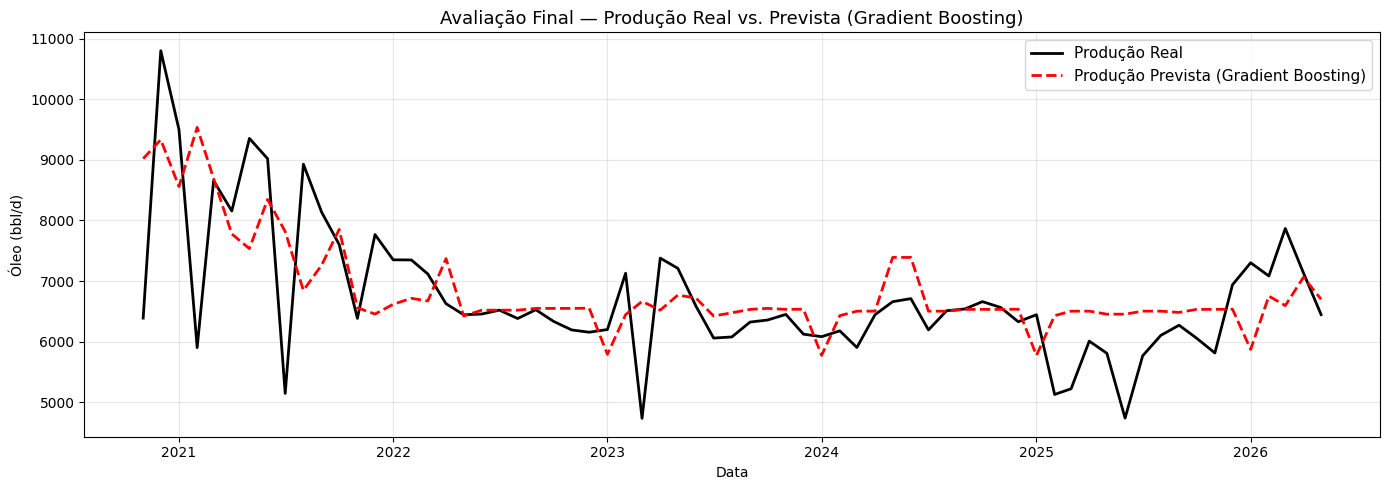

In [637]:
# === Gráfico Final: Real vs. Previsto ===
dates_test = df["data"].iloc[split_index:].values

plt.figure(figsize=(14, 5))
plt.plot(dates_test, y_test.values, label="Produção Real", color="black", linewidth=2)
plt.plot(dates_test, y_pred_final_model, label="Produção Prevista (Gradient Boosting)", color="red", linestyle="--", linewidth=2)
plt.title("Avaliação Final — Produção Real vs. Prevista (Gradient Boosting)", fontsize=13)
plt.xlabel("Data")
plt.ylabel("Óleo (bbl/d)")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Modelo final: Gradient Boosting


,MAE,RMSE,R2
Gradient Boosting,664.51,973.46,0.2066


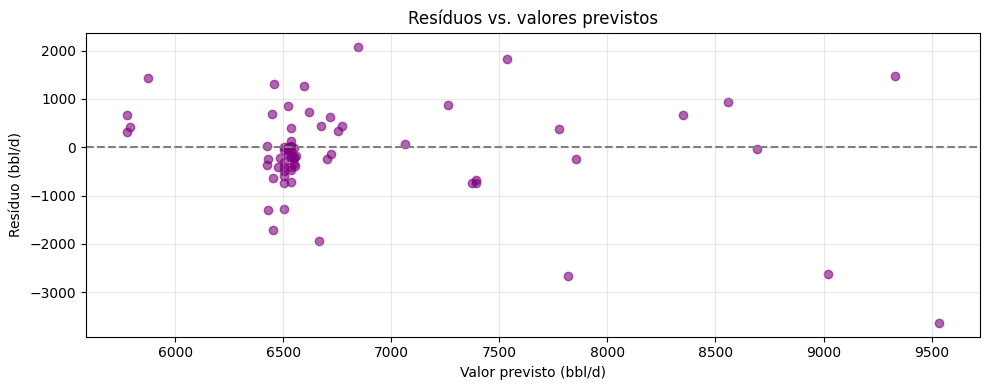

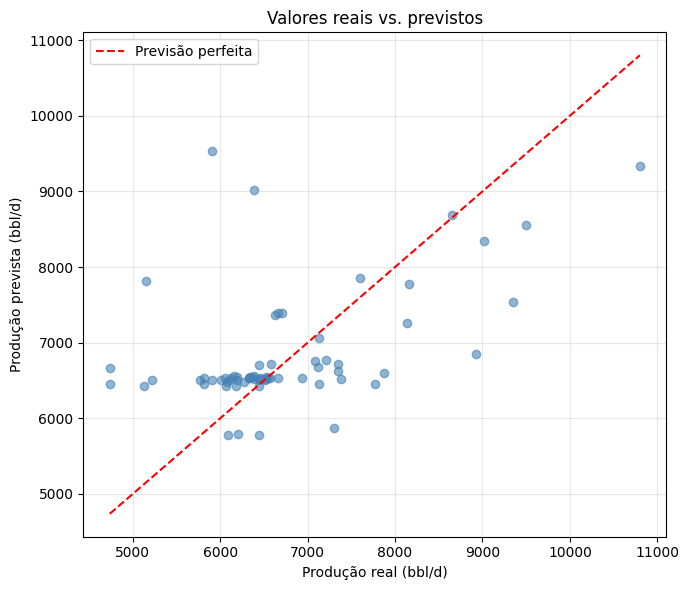

In [638]:
# === Avaliação final ===

final_model_name = "Gradient Boosting"
final_model = trained_models[final_model_name]

print("Modelo final:", final_model_name)

if final_model is not None and PROBLEM_TYPE == "classificacao":
    y_pred = final_model.predict(X_test)
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
    plt.title("Matriz de confusão — modelo final")
    plt.show()

elif final_model is not None and PROBLEM_TYPE == "regressao":
    y_pred = final_model.predict(X_test_scaled)
    display(pd.DataFrame([evaluate_regression(y_test, y_pred)], index=[final_model_name]))

    #Gráfico 1: resíduos vs valores previstos
    residuals = y_test - y_pred
    plt.figure(figsize=(10, 4))
    plt.scatter(y_pred, residuals, alpha=0.6, color="purple")
    plt.axhline(0, linestyle="--", color="gray")
    plt.title("Resíduos vs. valores previstos")
    plt.xlabel("Valor previsto (bbl/d)")
    plt.ylabel("Resíduo (bbl/d)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    #Gráfico 2: valores reais vs previstos (scatter)
    plt.figure(figsize=(7, 6))
    plt.scatter(y_test,y_pred, alpha=0.6, color="steelblue")
    min_val=min(y_test.min(), y_pred.min())
    max_val=max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Previsão perfeita")
    plt.title("Valores reais vs. previstos")
    plt.xlabel("Produção real (bbl/d)")
    plt.ylabel("Produção prevista (bbl/d)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, complemente a métrica com interpretação dos grupos e exemplos de cada cluster.")

elif PROBLEM_TYPE == "serie_temporal":
    print("Para séries temporais, compare valores reais vs. previstos ao longo do tempo.")

## 10.1 Análise de erros e limitações

**Resposta:**  

- Quais tipos de erro o modelo comete mais?  
O Gradient Boosting erra mais nos meses onde acontecem mudanças bruscas de produção.

- Há sinais de overfitting ou underfitting?  
O modelo baseline de regressão linear sinaliza underfitting (R2 = -22.8853), indicando que um modelo linear não pode representar a relação entre as variáveis. Já o Gradient Boosting otimizado sinalizou um overfitting (R2 caiu de 0.2066 para 0.1037 após busca por hiperparâmetros), indicando que a otimização forçou um ajuste exagerado ao treino. O modelo escolhido não apresenta sinais claros de overfitting (Gradient Boosting não otimizado).

- A métrica escolhida captura bem o objetivo do problema?  
Sim. O MAE é a métrica principal porque é interpretável diretamente na mesma unidade da variável-alvo, e não é excessivamente impactada por erros pontuais.

- Há viés, limitação de dados ou risco de generalização?  
Sim. O modelo utiliza apenas dados de produção fornecidos pela ANP, sem a disposição de dados adicionais. Por não conseguir prever flutuações de produção abruptas com clareza, o modelo tende a subestimar/superestimar os dados nessas condições. E o modelo foi treinado de forma exclusiva para um campo. Espera-se que funcione para campos análogos, mas podem ser necessárias adaptações para casos que sejam bastante diferentes.

- Em quais cenários o modelo não deveria ser usado?  
O modelo apresentado não deve ser usado para previsão de produção logo após eventos de parada de produção que impactem abruptamente o fluxo da produção. Nem em casos de campos com dinâmicas muito distintas do campo modelo analisado.

# 11. Comparação final dos modelos

Apresente uma síntese comparativa.

| Modelo | Métrica principal (MAE) | Outras métricas (RMSE/R2) | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline | 4904.50 | 5341.15/-22.8853 | 0.004 s | Desempenho fraco, relação não linear |
| Random Forest | 967.18 | 1211.66/-0.2292 | 0.231 s | Superou baseline; R2 negativo por margem pequena |
| Gradient Boosting | 664.51 | 973.46/0.2066 | 0.134 s | Melhor modelo, o único com R2 positivo |
| Gradient Boosting otimizado | 769.5 | 1034.66/0.1037 | 0.124 s | Modelo piorou. Overfitting na busca |

**Modelo escolhido:** Gradient Boosting (sem otimização). Apresentou o menor MAE e tem R2 positivo. Superou o baseline em 86%, e seu tempo de treino foi rápido.


# 12. Boas práticas e rastreabilidade

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Seed = 42 | Garantir reprodutibilidade | Resultados idênticos a cada execução |
| Divisão temporal 70/30 | Evitar vazamento de dados temporais | Avaliação mais realista do exercício |
| TimeSeriesSplit na otimização | Respeitar ordem cronológica na validação | Hiperparâmetros mais robustos |
| Features de lag | Usar apenas dados passados como input | Evitar look-ahead bias |
| Gradient Boosting como modelo final | Melhor MAE e R2 positivo | Maior precisão dentre os modelos apresentados |

* Modelos testados: baseline (regressão linear), Random Forest, Gradient Boosting, Gradient Boosting otimizado.

* Tempo aproximado de treino: menos de um minuto.

**Recursos computacionais usados:**
* Ambiente: Google Colab e suas ferramentas incorporadas.
* GitHub para hospedagem do notebook e dataset utilizados.

**Limitações conhecidas:**
* Não disponibilidade de dados de subsuperfície que ajudariam a projetar uma curva mais aproximada.

**O que foi descartado:**
* A otimização de hiperparâmetros não melhorou o resultado.

# 13. Conclusão

**Conclusão:**  
> Este MVP abordou a previsão de produção mensal de óleo do campo de Polvo, localizado no Brasil, bacia de Campos, e operado pela PRIO. Dados públicos da ANP foram utilizados nos modelos de Machine Learning.

* Principais tratamentos realizados:
  * Agregação mensal da produção total de Polvo;
  * Criação de features temporais: lags de produção, média móvel, meses de produção, número de poços ativos;
  * Criação de indicadores: GOR e water cut;
  * Divisão temporal 70/30 sem embaralhamento.

Dentre os modelos avaliados, o melhor resultado foi Gradient Boosting, sem otimização. MAE de 664.51 bbl/d e R2 de 0.2066. O critério de sucesso foi atingido, pois o Gradient Boosting superou o baseline em 86% em relação ao MAE, muito acima do critério estabelecido como mínimo de 10%.

Algumas limitações encontradas se referem à limitação de informação e dados como os de subsuperfície, e noções de eventos operacionais, como paradas de produção, que impactam diretamente nas previsões.

* Próximos passos:
  * Incluir dados adicionais na análise;
  * Testar modelagem por poço individual, ao invés de fazer por todo campo;
  * Implementar previsão recursiva para horizontes mais extensos, como 3, 6 e 12 meses;
  * Testar modelos de séries temporais para comparação.

O MVP realizado demonstrou que Machine Learning pode auxiliar na melhor aproximação na previsão de produção de óleo a partir de dados públicos, sendo mais eficaz do que uma análise linear simples. O Gradient Boosting reconheceu padrões de declínio não-lineares que uma regressão linear não é capaz de fazer com tamanha precisão.

# 14. Salvamento de artefatos

Seção não utilizada.


# 15. Apêndice opcional: Deep Learning, Fine-tuning ou métodos avançados

Seção não utilizada.
